In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import sys
sys.path.insert(1, '../../computational-aspects-of-machine-learning-project-3')
from src.torch_utils import load_model, predictions
#from FAR.utils import measure, read
from FAR.utils.read import RecoveryData, LogitToStat, DataProcessor, Merge
from FAR.utils.measure import Measure, Binning, CoincMass, SNRveto
from FAR.utils.plot import Plotting as pl
from FAR.utils.background import BackgroundFineTuner
from sklearn import metrics
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import warnings
from itertools import product
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['figure.dpi'] = 100

plt.style.use("seaborn-colorblind")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [2]:
# Some variables
path = '/data/gravwav/lopezm/Projects/GlitchBank/'
path_store = path + 'runs/background/results/'
timeslides_file = 'computational-aspects-of-machine-learning-project-3/FAR/timeslides_1132.9y.csv'
dark_colors = ['indigo','navy', 'mediumvioletred', 'darkgreen']
colors = ['mediumorchid','cornflowerblue', 'hotpink', 'mediumseagreen']
ifos = ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']
path_img = '../FAR/closedbox/' 
binning = Binning()
t_search = 0.5
far = [10, 1, 0.5,0.25, 0.1, 5e-2, 1e-2,5e-3, 1e-3, 5e-4,1e-4]
merge = Merge(path_store, path + timeslides_file)

In [3]:
path = '/data/gravwav/lopezm/Projects/GlitchBank/'
dp = DataProcessor(path + 'computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/', 
                   path + 'time_slides/', path + 'runs/injections/')
#all_tmps, _, _  = dp.getInjections()
#all_tmps.to_pickle(path + 'runs/injections/' + 'foreground.csv')
all_tmps = pd.read_pickle(path + 'runs/injections/' + 'foreground.csv')
print(len(all_tmps))


473511


In [ ]:
dt = np.concatenate([np.arange(0.01, 0.9, 0.01),
                     np.asarray([0.9, 0.99, 0.999, 0.9999, 0.99999, 0.999999,0.9999999])])
fig, axs = plt.subplots(1, 2, dpi=120)
for c, ifo in zip(colors, ifos):
    print(ifo)
    tprs, fprs = [], []
    t_bkg, bkg = merge.mergeTriggers(ifo.replace('1', "")) # FIXME
    x, y, p = binning.fit_and_binning(data=bkg['rank_stat_'+ifo], rank=3)
    # Variables: either counts, far or events
    y_obs, ylabel = binning.yVar(y, 'far', t_bkg, t_search)
    pos = all_tmps.copy()
    neg = bkg.copy()
    for d in dt:
        p_star = - np.log(1 - d + 1e-20)
        # We only consider post GstLAL
        tp, p, _, _ = Measure.TPR(pos, ifo, p_star=p_star)
        tpr = tp /p * 100
        fpr = Measure.FPR(neg, ifo, p_star=p_star)
        tprs.append(tpr)
        fprs.append(fpr)
        print(d, tpr, fpr)
    correction = (100 - max(fprs))*max(tprs)
    auc = metrics.auc(fprs, tprs) + correction
    print(auc)
    if len(ifo) == 4: ax = axs[0]
    else: ax = axs[1]
    ax.plot(fprs, tprs, marker='o', c=c, markersize=2,
             label=ifo)
    ax.set_xlabel('FPR'), ax.set_ylabel('TPR')
    ax.legend()

plt.tight_layout()
# Save the figure as PNG
plt.savefig(path_img +'roc_novetoes.png', dpi=300)  # Set dpi for high resolution

# Save the figure as PDF
plt.savefig(path_img +'roc_novetoes.pdf')

None 4598.962 28508 354214
6.0 5435.007 20257 94652
5.9 5417.011 20569 99787
5.800000000000001 5410.525 20893 105513
5.700000000000001 5396.884 21234 111777
5.600000000000001 5383.783 21554 117946
5.500000000000002 5375.798 21914 125120
5.400000000000002 5363.212 22253 133007
5.3000000000000025 5350.01 22603 142012
5.200000000000003 5331.998 22965 152242
5.100000000000003 5313.752 23331 163960
5.0000000000000036 5280.723 23697 178052
4.900000000000004 5247.658 24058 194317
4.800000000000004 5210.502 24444 213710
4.700000000000005 5163.887 24827 235758
4.600000000000005 5112.656 25234 260027
4.500000000000005 5052.25 25670 285311
4.400000000000006 4994.592 26053 309505
4.300000000000006 4929.609 26502 330679
4.200000000000006 4842.424 27030 345849
4.100000000000007 4740.385 27637 353116
4.000000000000007 4598.962 28508 354214
None 4598.962 28508 354214
6.0 5435.007 20257 94652
5.9 5417.011 20569 99787
5.800000000000001 5410.525 20893 105513
5.700000000000001 5396.884 21234 111777
5.6000

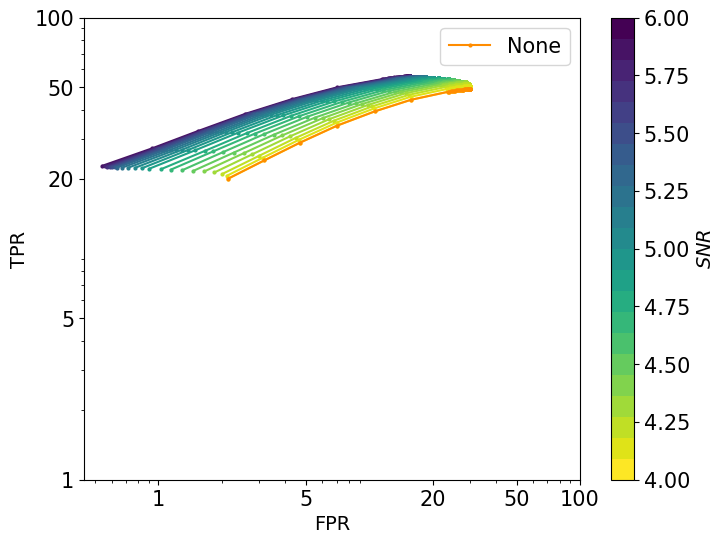

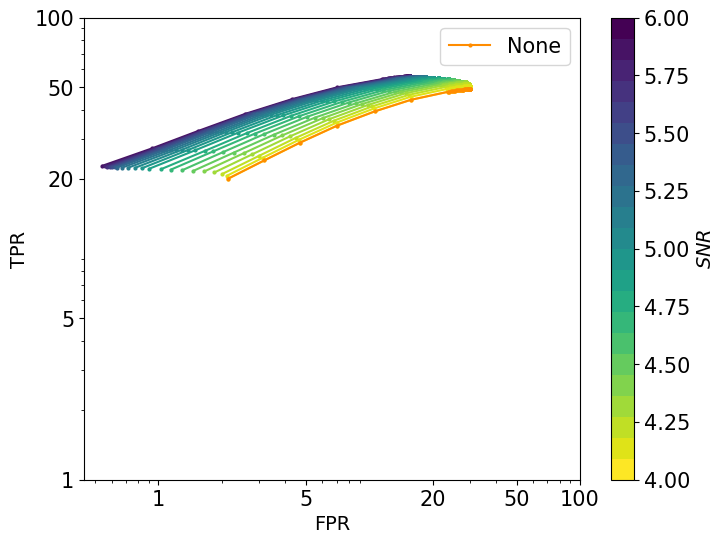

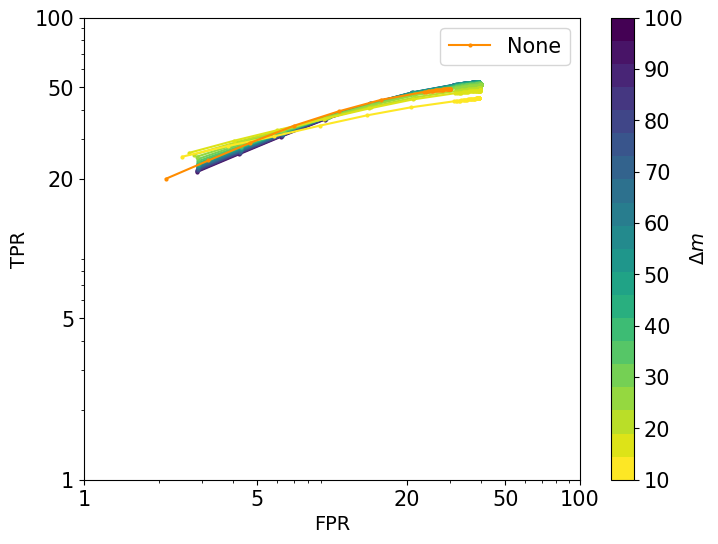

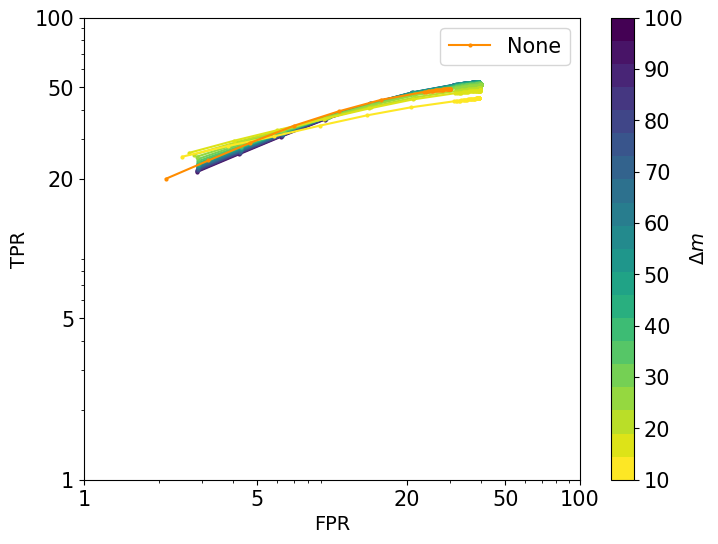

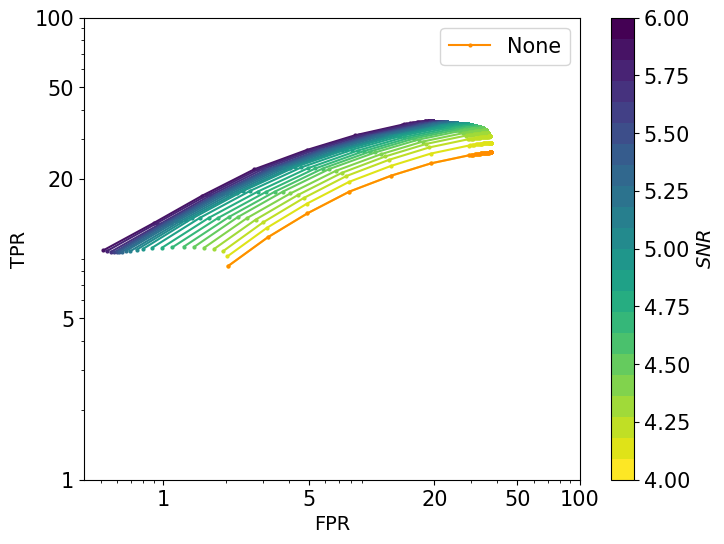

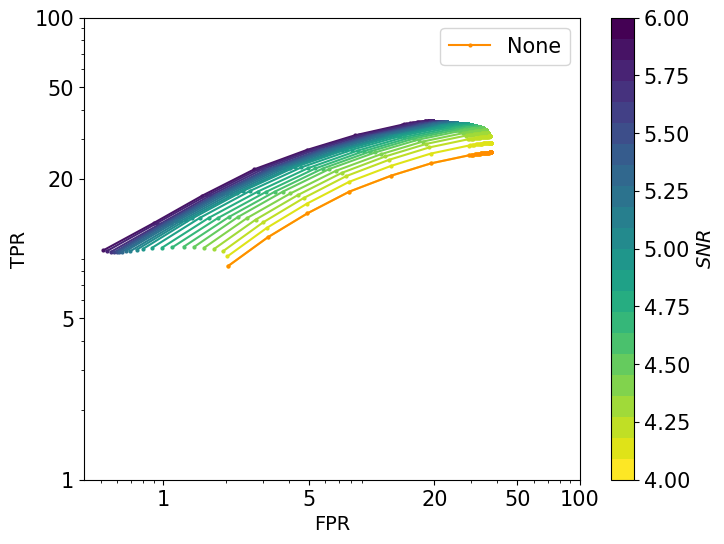

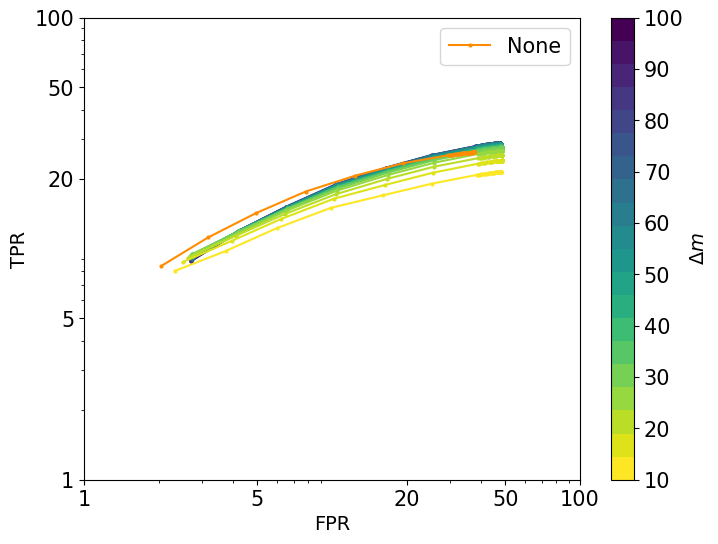

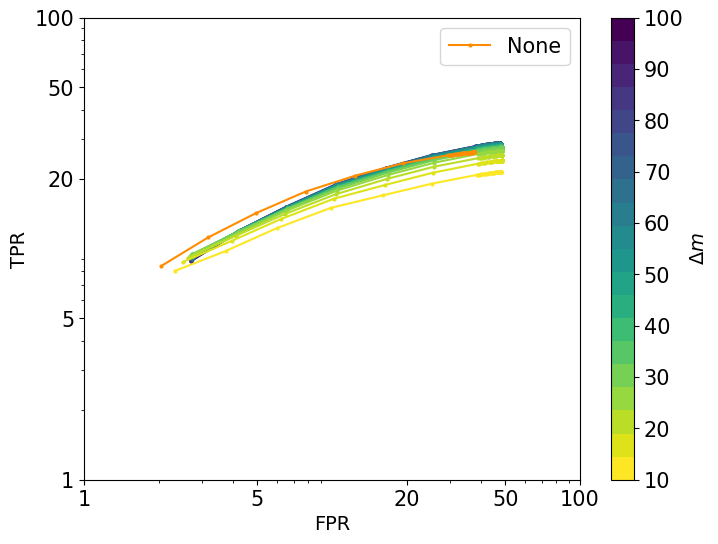

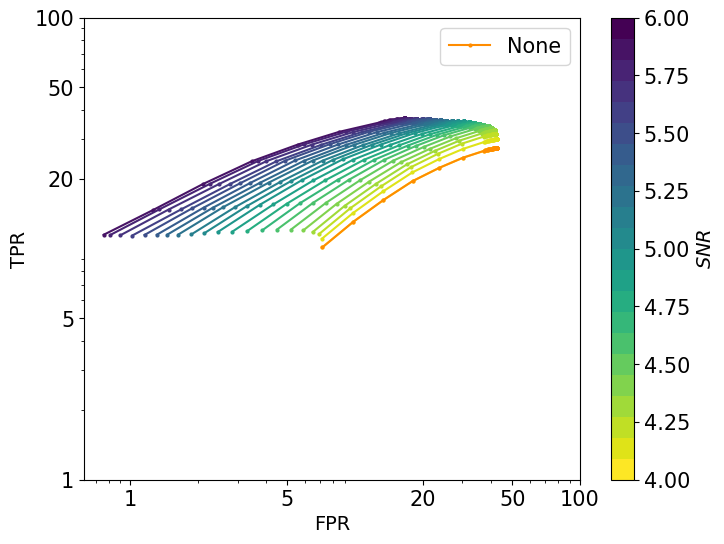

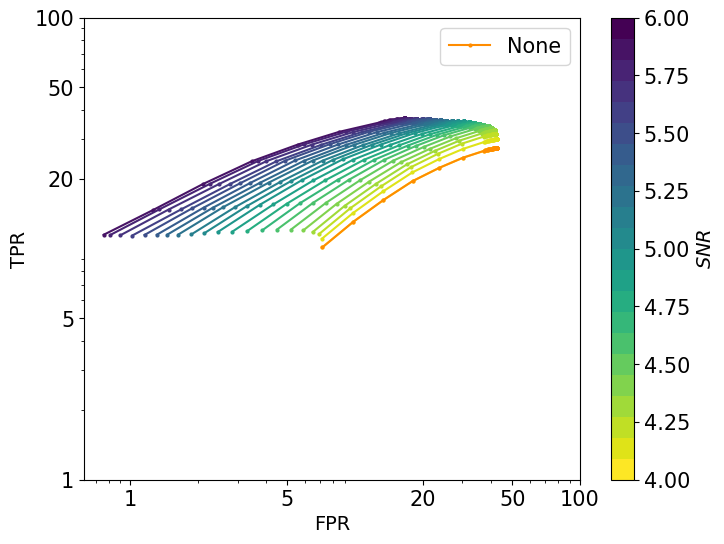

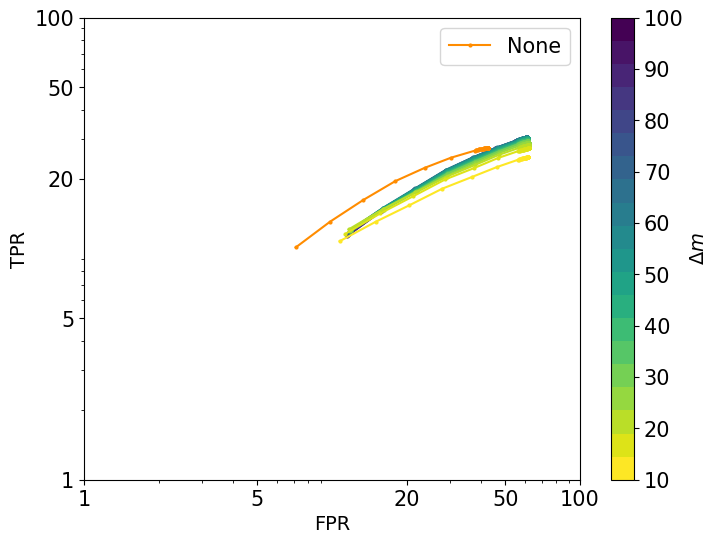

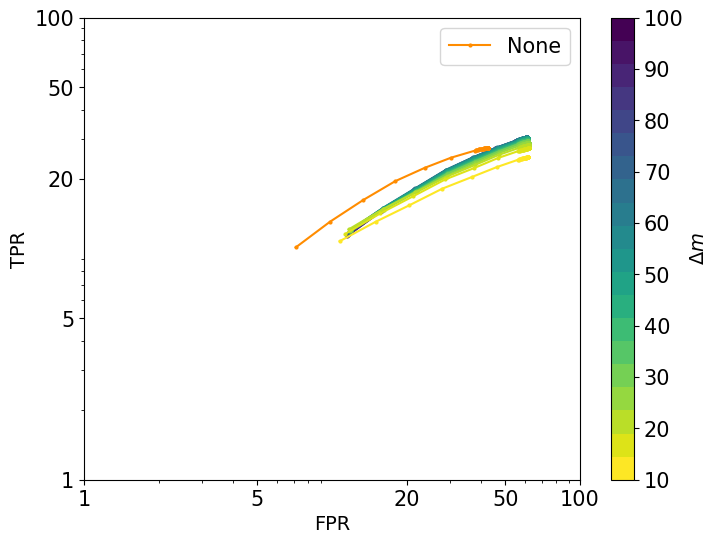

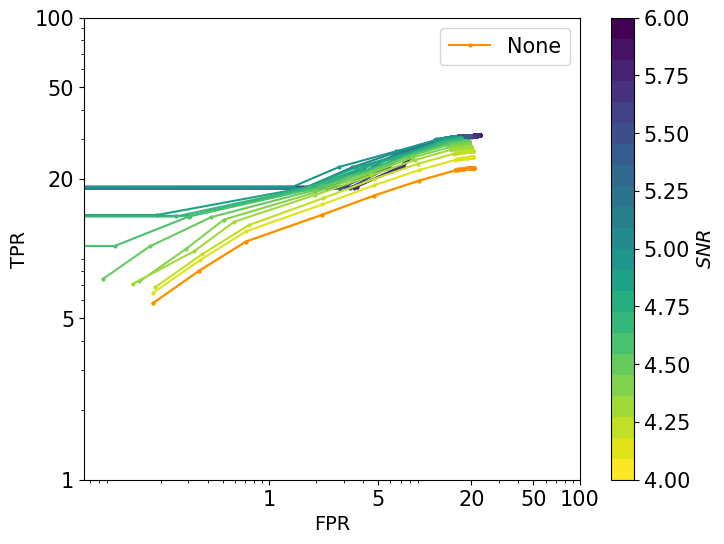

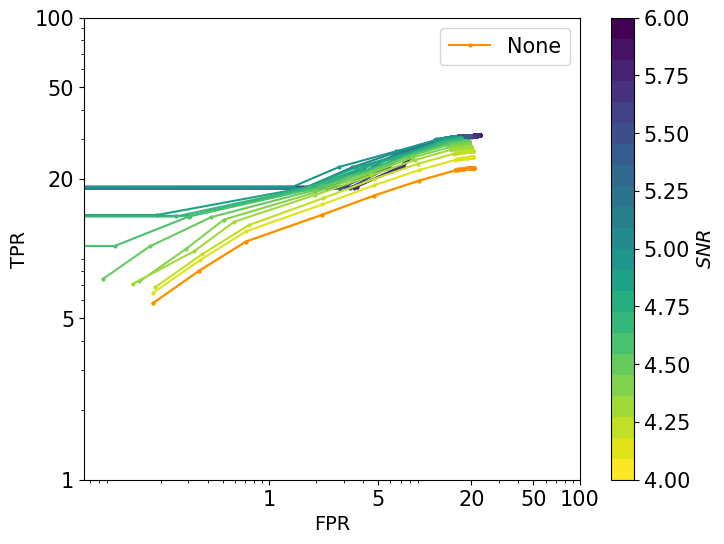

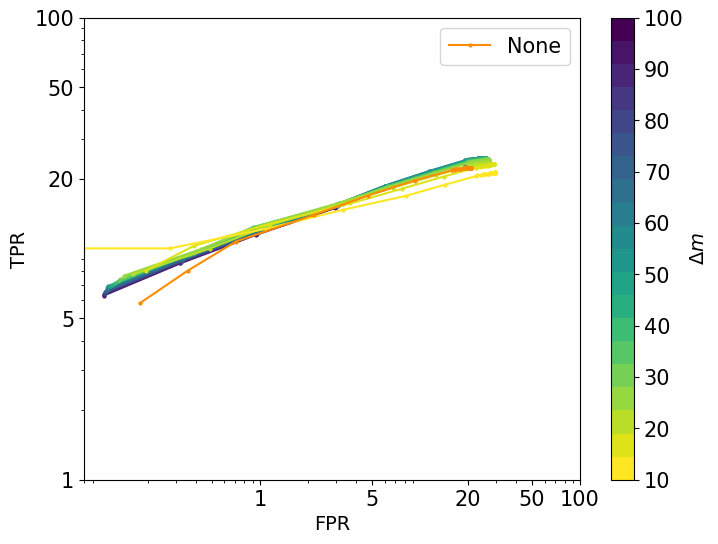

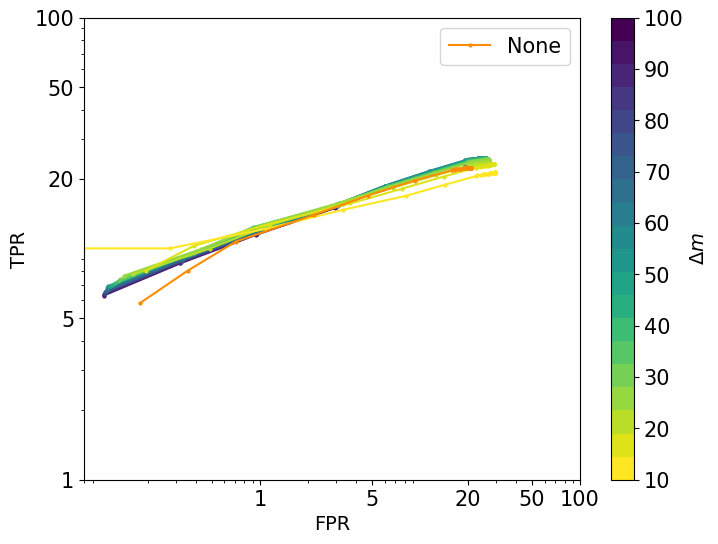

In [4]:
%%time
merge = Merge(path_store, path + timeslides_file)
I, t_search = ['H1L1', 'H1V1', 'L1V1', 'H1L1V1'], 0.5

aucs_m, aucs_snr = [], []
for ifos in I:
    # Call the background
    t_bkg, bkg = merge.mergeTriggers(ifos.replace('1', "")) # FIXME
    if len(ifos) == 4:
        bkg.columns = [col + '1' if i < len(bkg.columns) - 2 else col for i, col in enumerate(bkg.columns)]
    for xlabel, auc_list in product([r'$SNR$', r'$\Delta m$'], [aucs_snr, aucs_m]):
        tprs, fprs, aucs, vetoes = BackgroundFineTuner(ifos, t_search, t_bkg).fine_tune_bkg(all_tmps, bkg, xlabel)
        auc_list.append(aucs)

4598.962
2407.95
2336.709
2172.178


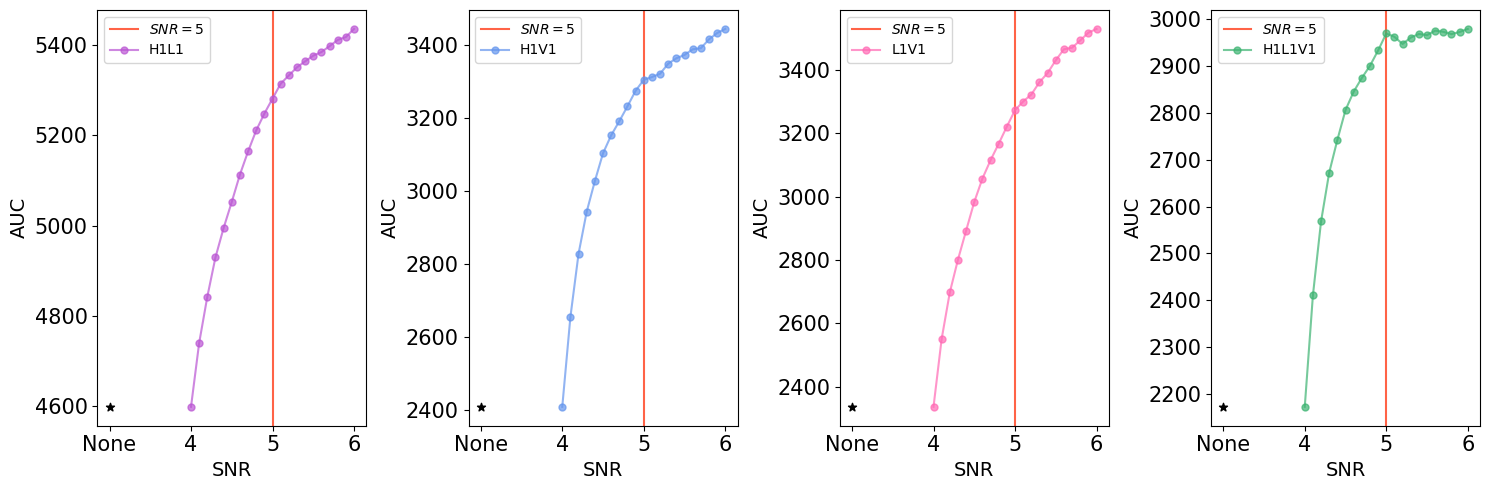

4598.962
60
2407.95
80
2336.709
65
2172.178
60


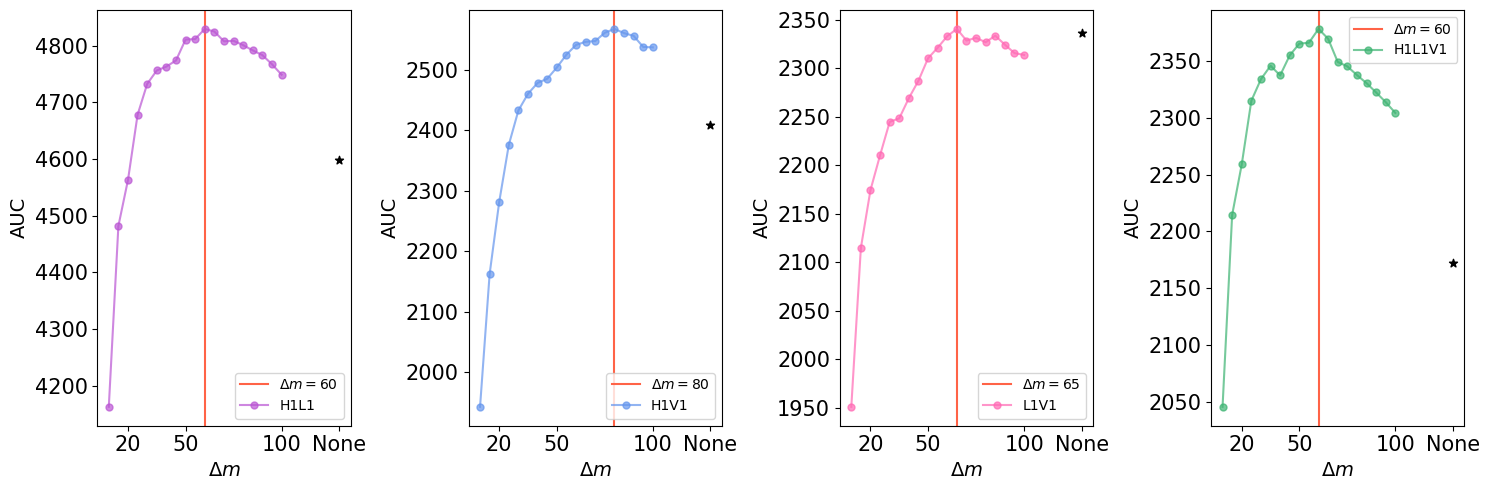

In [28]:
vetoes_mass = np.arange(100, 5, -5).tolist()
vetoes_snr = np.arange(6, 3.9, -0.1).tolist() 

for vetoes, labels, name in zip([vetoes_snr, vetoes_mass], ['SNR', r'$\Delta m$'], ['snr', 'mass']):
    # Create subplots
    fig, axes = plt.subplots(nrows=1, ncols=len(I), figsize=(15, 5), sharex=True)
    
    # Iterate over interferometers and plot in subplots
    for i, (ax, ifos, c) in enumerate(zip(axes, I, colors)):
        print(auc_list[2 * i][0])
        if labels == 'SNR':
            ax.scatter([3], auc_list[2 * i][0], c='black', marker='*', zorder=10)
            ax.set_xticks([3, 4, 5, 6]), ax.set_xticklabels(['None', 4, 5, 6])
            ax.axvline(5, c='tomato', label=r'$SNR = $'+ str(5))
            y = auc_list[2 * i][1:]
        else:
            y = auc_list[2 * i + 1][1:]
            print(vetoes[np.argmax(auc_list[2 * i + 1][1:])])
            ax.axvline(vetoes[np.argmax(auc_list[2 * i + 1][1:])],
                       c='tomato', label=r'$\Delta m = $'+ str(vetoes[np.argmax(auc_list[2 * i + 1][1:])]))
            ax.scatter([130], auc_list[2 * i + 1][0], c='black', marker='*', zorder=10)
            ax.set_xticks([1, 20, 50, 100, 130]), ax.set_xticklabels([1, 20, 50, 100, 'None'])
        ax.plot(vetoes, y, label=ifos, marker='o', markersize=5, c=c, alpha=0.7)
        ax.set_xlabel(labels)
        ax.set_ylabel('AUC')
        ax.legend(fontsize=10)
    
    # Adjust layout to prevent overlap
    # Save the figure as PNG
    plt.tight_layout()
    plt.savefig(path_img +'roc_all_'+name+'.png', dpi=300)  # Set dpi for high resolution
    
    # Save the figure as PDF
    plt.savefig(path_img +'roc_all_'+name+'.pdf')
    plt.show()

In [ ]:
theta_star = 0.9
bins_dist = np.arange(0, 20000, 1000)
bins_snr = np.concatenate([np.arange(0, 9), np.arange(10, 19, 2), np.arange(20, 55, 5)])
for bins, xlabel in zip([bins_dist, bins_snr], [r'Luminosity distance ($D_{L}$)', 'Injected SNR']):
    for ifo, bcolor, color in zip(['H1L1', 'L1V1', 'H1V1'], ['royalblue', 'sienna', 'forestgreen'], colors): 

        if xlabel == 'Injected SNR':
            ycol = 'injSNR'+ifo
        else:
            ycol = 'Distance'
        test = all_tmps[~all_tmps['P_inj_'+ifo].isna()]
        
        TPR, yerr, mean_var, xerr = [], [], [], []
        for b in range(len(bins)):
            if bins[b] != max(bins):
                select = test[(test[ycol] >= bins[b])  & (test[ycol] <= bins[b+1])]
            else:
                select = test[(test[ycol] >= bins[b])]
            tp = len(select[(select['P_inj_'+ifo] >= theta_star)])
            yerr.append(np.sqrt(tp/(len(select)**3)))
            TPR.append(tp/len(select))
            mean_var.append(np.mean(select[ycol]))
            xerr.append(3*np.std(select[ycol])/len(select))

        plt.plot(mean_var, TPR, label=ifo, c=color)
        plt.errorbar(mean_var, TPR, yerr=yerr, xerr=xerr,
                     fmt='o', capsize=2, color=bcolor, markerfacecolor=color, markersize=1, zorder=1)

        plt.xlabel(xlabel)
        plt.ylabel('TPR')
    plt.legend()
    plt.show()
#select = test[(test['injSNR'+ifo] >= 50) & (test['injSNR'+ifo] <= upper_bound)]

In [ ]:
def getHarm2(data, ifo1, ifo2):
    mask = data['P_inj_'+ifo1].notna() & data['P_inj_'+ifo2].notna()
    selected_rows = data[mask]
    harm2 = Measure().harmonic2coinc(selected_rows['P_inj_'+ifo1].values, selected_rows['P_inj_'+ifo2].values)
    data['P_inj_'+ifo1+ifo2] = np.nan
    data.loc[mask, 'P_inj_'+ifo1+ifo2] = harm2
    return data

def getHarm3(data):
    mask = data['P_inj_H1'].notna() & data['P_inj_L1'].notna() & data['P_inj_V1'].notna() 
    selected_rows = data[mask]
    harm3 = Measure().harmonic3coinc(selected_rows['P_inj_H1'].values, selected_rows['P_inj_L1'].values, selected_rows['P_inj_V1'].values)
    data['P_inj_all'] = np.nan
    data.loc[mask, 'P_inj_all'] = harm3
    return data

def netSNR2(data, ifo1, ifo2):

    mask = data['injSNR'+ifo1].notna() & data['injSNR'+ifo2].notna()
    selected_rows = data[mask]
    a = np.asarray(selected_rows['injSNR'+ifo1], dtype=float)
    b = np.asarray(selected_rows['injSNR'+ifo2], dtype=float)

    netsnr = np.sqrt(a**2 + b**2)
    data['injSNR'+ifo1+ifo2] = np.nan
    data.loc[mask, 'injSNR'+ifo1+ifo2] = netsnr
    return data

def netSNR3(data, ifo1, ifo2, ifo3):

    mask = data['injSNR'+ifo1].notna() & data['injSNR'+ifo2].notna() & data['injSNR'+ifo3].notna()
    selected_rows = data[mask]
    a = np.asarray(selected_rows['injSNR'+ifo1], dtype=float)
    b = np.asarray(selected_rows['injSNR'+ifo2], dtype=float)
    c = np.asarray(selected_rows['injSNR'+ifo3], dtype=float)
    netsnr = np.sqrt(a**2 + b**2 + c**2)
    data['injSNRall'] = np.nan
    data.loc[mask, 'injSNRall'] = netsnr
    return data

    
all_tmps = getHarm2(all_tmps, 'H1', 'L1')
all_tmps = getHarm2(all_tmps, 'L1', 'V1')
all_tmps = getHarm2(all_tmps, 'H1', 'V1')
all_tmps = getHarm3(all_tmps)
all_tmps = netSNR2(all_tmps, 'H1', 'L1')
all_tmps = netSNR2(all_tmps, 'L1', 'V1')
all_tmps = netSNR2(all_tmps, 'H1', 'V1')
all_tmps = netSNR3(all_tmps, 'H1', 'L1', 'V1')


In [ ]:
def percentageNotNan(data, col):
    per = data[col].notna().mean() * 100
    return per
for cols in  ['H1', 'L1', 'V1', 'H1L1', 'L1V1', 'H1V1', 'all']:
    print(cols, percentageNotNan(all_tmps, 'P_inj_'+cols))
    

In [ ]:
def computeCounts(data, ifo, bins, ycol, theta_star): 
    tmp = data[~data['P_inj_'+ifo].isna()]
    TPR, yerr, mean_var, xerr = [], [], [], []
    for b in range(len(bins)):
        if bins[b] != max(bins):
            select = tmp[(tmp[ycol] >= bins[b])  & (tmp[ycol] <= bins[b+1])]
        else:
            select = tmp[(tmp[ycol] >= bins[b])]
        ranking_stat = - np.log(1 - select['P_inj_'+ifo] + 1e-11)
        tp = len(select[(ranking_stat >= theta_star)])

        yerr.append(np.sqrt(tp/(len(select)**3)))
        TPR.append(tp/len(select))
        mean_var.append(np.mean(select[ycol]))
        xerr.append(3*np.std(select[ycol])/len(select))
    return TPR, yerr, mean_var, xerr

def plotDistandSNR(data, theta_star, var):

    # Define variables
    bins_dist = np.arange(0, 20000, 1000)
    bins_snr = np.concatenate([np.arange(0, 9), np.arange(10, 19, 2), np.arange(20, 55, 5)])
   
    ifos = ['H1L1', 'L1V1', 'H1V1', 'all']
    colors = ['violet', 'goldenrod', 'aqua', 'grey']
    bcolors = ['violet', 'goldenrod', 'aqua', 'grey']
    # ifos = ['H1', 'L1', 'V1', 'H1L1', 'L1V1', 'H1V1', 'all']
    # colors = ['cornflowerblue', 'tomato', 'mediumseagreen', 'violet', 'goldenrod', 'aqua', 'grey']
    # bcolors = ['cornflowerblue', 'tomato', 'mediumseagreen', 'violet', 'goldenrod', 'aqua', 'grey']

    if var == 'SNR':
        bins, xlabel = bins_snr, 'Injected SNR'
    elif var == 'distance':
        bins, xlabel = bins_dist, r'Luminosity distance ($D_{L}$)'

    for ifo, bcolor, color in zip(ifos, bcolors, colors): 
        
        if xlabel == 'Injected SNR': ycol = 'injSNR'+ifo
        else: ycol = 'Distance'
        
        TPR, yerr, mean_var, xerr = computeCounts(data, ifo, bins, ycol, theta_star)
        
        plt.plot(mean_var, TPR, label=ifo, c=color)
        plt.errorbar(mean_var, TPR, yerr=yerr, xerr=xerr,
                     fmt='o', capsize=2, color=bcolor,
                     markerfacecolor=color, markersize=1, zorder=1)
        plt.xlabel(xlabel)
        if 'SNR' in xlabel:
            plt.xscale('log'), plt.xticks(x, x)
        plt.ylabel('TPR')
    plt.legend(), plt.ylim(0, 1), plt.grid(True)
    plt.show()
    
plotDistandSNR(all_tmps, 12, 'SNR')
plotDistandSNR(all_tmps, 12, 'distance')